<h1>Calculate and plot differences</h1>

In [1]:
import sys
import os

# Add the path to the `simulated_recons/` folder to the Python path
sys.path.append(os.path.abspath("../../.."))
sys.path.insert(0, '/mxn/home/reblex/.local/lib/python3.8/site-packages')
import livedifferences

from ptypy import io
from ptypy.utils import rmphaseramp
import numpy as np
import re
import glob
from skimage.registration import phase_cross_correlation
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import scipy
import matplotlib.pyplot as plt
from scipy.ndimage import shift

%matplotlib widget
plt.ion()

WARNING ptypy - Message Passaging for Python (mpi4py) not found.
    CPU-parallelization disabled.
    Install python-mpi4py via the package repositories or with `pip install --user mpi4py`


<h2>Load data</h2>

In [163]:
scan = "000031"

npzfile = np.load("recon_info.npz", allow_pickle=True)
npzfile.files
offl_info = list(npzfile['offl_info'])
live_info = list(npzfile['live_info'])
livesim_info = list(npzfile['livesim_info'])


recset = []
#scanset = [recon for recon in offl_info+live_info if recon["sample"]=="siemens_big"]
recset = [recon for recon in offl_info+live_info if recon["scan"]==scan]
#recset_offl = [recon for recon in offl_info if recon["sample"]=="siemens_big"]
#recset_live = [recon for recon in live_info if recon["sample"]=="siemens_big"]

recset_offl = [recon for recon in offl_info if recon["scan"]==scan]
recset_live = [recon for recon in live_info if recon["scan"]==scan]
recset_livesim = [recon for recon in livesim_info if recon["scan"]==scan]

print(f"{recset_offl[0]['rec_path']}\n\n {recset_live[0]}\n\n {recset_livesim}")

## Difference of real live
LD = livedifferences.LoadData(offline_fname=recset_offl[0]['rec_path'][0], realtime_fname=recset_live[0]['rec_path'][0], samplename=scan)

## Difference of livesims:
#LD = livedifferences.LoadData(offline_fname=recset_offl[1]['rec_path'][-1], realtime_fname=recset_livesim[0]['rec_path'][-1], samplename=f"{scan}_poscorr")

LD.load()
LD.obj1.shape, LD.obj2.shape

['/data/visitors/nanomax/20250057/2025021508/process/RL/OfflinePtycho/10micron_tungsten/000031_00/rec/rec_scan_000000_DM_pycuda_1984.ptyr']

 {'scan': '000031', 'recfoldername': '000031_00', 'sample': '10micron_tungsten', 'nriter': 1984, 'rec_path': ['/data/visitors/nanomax/20250057/2025021508/process/RL/LivePtycho/10micron_tungsten/000031_00/rec/rec_scan_000001_DM_pycuda_1984.ptyr'], 'rawdata_paths': ['/data/visitors/nanomax/20250057/2025021508/raw/0001_setup/000031.h5', '/data/visitors/nanomax/20250057/2025021508/raw/0001_setup/scan_000031_eiger1m.hdf5']}

 []


((2354, 2327), (2354, 2327))

In [164]:
recset_livesim

[]

In [165]:
recset_offl

[{'scan': '000031',
  'recfoldername': '000031_00',
  'sample': '10micron_tungsten',
  'nriter': 1984,
  'rec_path': ['/data/visitors/nanomax/20250057/2025021508/process/RL/OfflinePtycho/10micron_tungsten/000031_00/rec/rec_scan_000000_DM_pycuda_1984.ptyr'],
  'rawdata_paths': ['/data/visitors/nanomax/20250057/2025021508/raw/0001_setup/000031.h5',
   '/data/visitors/nanomax/20250057/2025021508/raw/0001_setup/scan_000031_eiger1m.hdf5']}]

In [166]:
LD.fname1, LD.fname2

('/data/visitors/nanomax/20250057/2025021508/process/RL/OfflinePtycho/10micron_tungsten/000031_00/rec/rec_scan_000000_DM_pycuda_1984.ptyr',
 '/data/visitors/nanomax/20250057/2025021508/process/RL/LivePtycho/10micron_tungsten/000031_00/rec/rec_scan_000001_DM_pycuda_1984.ptyr')

In [167]:
LD.process_data() # Gives obj1_abs, obj2_abs, obj1_abslog, obj2_abslog, obj1_phase, obj2_phase, w1, w2, obj1_ramp, ramp1, obj2_ramp, ramp2, obj1_phaseramp, obj2_phaseramp, obj1_phaseramp_unwrapped, obj2_phaseramp_unwrapped, obj1_rmramp_abs, obj2_rmramp_abs, obj1_rmramp_abslog, obj2_rmramp_abslog, diff_rmramp_abslog, diff_abslog_od, diff_phase, diff_phaseramp, diff_phaseramp_unwrapped, diff_phaseramp_unwrapped_ramp, shift1, error, phasediff
#print(LD.sh, LD.sh1, LD.obj1_phaseramp_unwrapped_pad.shape)
########
#LD10.process_data() # Gives obj1_abs, obj2_abs, obj1_abslog, obj2_abslog, obj1_phase, obj2_phase, w1, w2, obj1_ramp, ramp1, obj2_ramp, ramp2, obj1_phaseramp, obj2_phaseramp, obj1_phaseramp_unwrapped, obj2_phaseramp_unwrapped, obj1_rmramp_abs, obj2_rmramp_abs, obj1_rmramp_abslog, obj2_rmramp_abslog, diff_rmramp_abslog, diff_abslog_od, diff_phase, diff_phaseramp, diff_phaseramp_unwrapped, diff_phaseramp_unwrapped_ramp, shift1, error, phasediff
#LD10.add_padding() # Gives sh, sh1, padrow, padcol, obj1_pad, obj2_pad, obj1_abs_pad, obj2_abs_pad, obj1_abslog_pad, obj2_abslog_pad, obj1_phase_pad, obj2_phase_pad, obj1_ramp_pad, obj2_ramp_pad, obj1_rmramp_abs_pad, obj2_rmramp_abs_pad, obj1_rmramp_abslog_pad, obj2_rmramp_abslog_pad, obj1_phaseramp_pad, obj2_phaseramp_pad, obj1_phaseramp_unwrapped_pad, obj2_phaseramp_unwrapped_pad
#print(LD10.sh, LD10.sh1, LD10.obj1_phaseramp_unwrapped_pad.shape)



<h2>Calculate</h2>

In [168]:
def get_difference(obj_a, obj_b, rampscale=100, upsamp=1):
    """Get the optical density and phase difference between obj_a and the reference obj_b"""
    shift_ab,_,phase_shift = phase_cross_correlation(obj_a, obj_b, upsample_factor=upsamp)
    print(f'shift: {shift_ab}, phase_shift: {phase_shift}')
    
    #shift
    #shift2GT = phase_cross_correlation(LD10.obj_ramp[LD40.sh[1]//2-sz:LD40.sh[1]//2+sz, LD40.sh[0]//2-sz:LD40.sh[0]//2+sz], LD40.obj2_ramp_pad[LD40.sh[1]//2-sz:LD40.sh[1]//2+sz, LD40.sh[0]//2-sz:LD40.sh[0]//2+sz], upsample_factor=100, return_error=False)
    obj_a = shift(obj_a, -shift_ab, mode="constant", cval=0+0j)
    
    W1 = LD.rampweight_(obj_a, scale=rampscale)#
    all_ramps1 = {}
    all_ramps2 = {}
    #W1 = LD.rampweight(obj_a, scale=100)#
    for nr_removal in range(5):
        obj_a, all_ramps1[nr_removal] = rmphaseramp(obj_a, W1, return_phaseramp=True)
        obj_b, all_ramps2[nr_removal] = rmphaseramp(obj_b, W1, return_phaseramp=True)


    
    
    
    obj_b *= np.mean(np.abs(obj_a) / np.abs(obj_b)) # Scale the reconstruction to the solution

    phase_error = np.angle(obj_b) + phase_shift - np.angle(obj_a) # same as np.angle(obj_b*np.exp(1.0j*phase_shift)) - np.angle(obj_a)
    phase_error[phase_error < np.pi] += 2*np.pi
    phase_error[phase_error > np.pi] -= 2*np.pi

    OD_diff = np.log(np.abs(obj_b)) - np.log(np.abs(obj_a))
    print('np.mean(np.log(np.abs(obj_b)))', np.mean(np.log(np.abs(obj_b))))

    return OD_diff, phase_error, all_ramps1, all_ramps2


In [169]:
# Normalized mean-squeared error

def NMSE(obj1_, obj2_, printoutput=True):
    """Calculated as in eqn (8) and (9) in Maiden, A. M. & Rodenburg, J. M. An improved ptychographical phase retrieval algorithm for diffractive imaging.
Ultramicroscopy 109, 1256–1262 (2009)."""
    W1 = LD.rampweight(obj1_, scale=100)#
    obj1_ = rmphaseramp(obj1_, W1)
    obj1_ = rmphaseramp(obj1_, W1)
    obj1_ = rmphaseramp(obj1_, W1)
    obj1_ = rmphaseramp(obj1_, W1)
    obj1_ = rmphaseramp(obj1_, W1)
    obj2_ = rmphaseramp(obj2_, W1)
    obj2_ = rmphaseramp(obj2_, W1)
    obj2_ = rmphaseramp(obj2_, W1)
    obj2_ = rmphaseramp(obj2_, W1)
    obj2_ = rmphaseramp(obj2_, W1)


    gamma12 = ( np.sum( obj1_*np.conjugate(obj2_) ) ) / (np.sum( np.abs(obj2_)**2 ))
    gamma21 = ( np.sum( obj2_*np.conjugate(obj1_) ) ) / (np.sum( np.abs(obj1_)**2 ))  # Just to ensure the order doesn't matter

    #print(np.abs(gamma1), np.mean(np.abs(obj_GT)/np.abs(obj1_)))
    E12 = ( np.sum( np.abs(obj1_-gamma12*obj2_)**2 ) ) / ( np.sum( np.abs(obj1_)**2 ) )
    E21 = ( np.sum( np.abs(obj2_-gamma21*obj1_)**2 ) ) / ( np.sum( np.abs(obj2_)**2 ) )  # Just to ensure the order doesn't matter
    
    if printoutput:
        print(f'NMSE(obj1_,  obj2_): {E12:.2e}')
        print(f'NMSE(obj2_,  obj1_): {E21:.2e}')


    #### Peak signal to noise ratio
    MSE12 = np.mean(np.abs(obj1_ - obj2_)**2)

    max_val1 = np.max(np.abs(obj1_))


    PSNR12 = 10 * np.log10(max_val1**2 / MSE12)
    
    if printoutput:
        print('PSNR: ', PSNR12)
    return E12


<h2>Reconstruction difference</h2>

In [170]:
scale=30
start_M, end_M, start_N, end_N = LD.get_margin(LD.obj1, scale=scale)
start_M, end_M, start_N, end_N

print(LD.obj1[start_M:end_M, start_N:end_N].shape)

margMN = LD.get_margin(LD.obj1, scale=scale)
LD.obj1
margMN
Mslice = slice(351, 1054)
Nslice = slice(345, 1035)
print(LD.obj1[Mslice,Nslice].shape)

(707, 698)
(703, 690)


In [171]:
# Calculate differences
scale=45
start_M, end_M, start_N, end_N = LD.get_margin(LD.obj1, scale=scale)
#marg = 350
obj1_ = np.array(LD.obj1[start_M:end_M, start_N:end_N].copy())
obj2_ = np.array(LD.obj2[start_M:end_M, start_N:end_N].copy())
#obj1_ = np.array(LD.obj1[marg:-marg,marg:-marg].copy())
#obj2_ = np.array(LD.obj2[marg:-marg,marg:-marg].copy())

E12 = NMSE(obj1_, obj2_, printoutput=True)
OD_diff21, phase_error21, all_ramps1, all_ramps2 = get_difference(obj1_, obj2_, rampscale=100, upsamp=1)

lim_od21 = np.max(np.abs([ np.min(OD_diff21), np.max(OD_diff21[np.where(np.isfinite(OD_diff21))])])) # the shift function causes inf values in the logabsdiff on 2 of the edges.
#lim_ph21 = np.max(np.abs([ np.min(phase_error21), np.max(phase_error21)]))
lim_ph21 = np.max(np.abs([ np.min(phase_error21), np.max(phase_error21[np.where(np.isfinite(OD_diff21))])]))

print('limit ', lim_od21, lim_ph21)

# ################## For differently sized objects due to position refinement:

# # Calculate differences
# scale=45
# #marg = 350
# sh1 = LD.obj1.shape
# sh2 = LD.obj2.shape
# LD.obj2_croplike1_ = LD.obj2[:sh1[0]-170, :sh1[1]-170].copy()
# LD.obj1_croplike1_ = LD.obj1[:sh1[0]-170, :sh1[1]-170].copy()
# start_M, end_M, start_N, end_N = LD.get_margin(LD.obj1_croplike1_, scale=scale)


# obj1_ = np.array(LD.obj1_croplike1_[start_M:end_M, start_N:end_N].copy())
# obj2_ = np.array(LD.obj2_croplike1[start_M:end_M, start_N:end_N].copy())
# print(f'obj1_.shape: {obj1_.shape}, obj2_.shape: {obj2_.shape}')

# E12 = NMSE(obj1_, obj2_, printoutput=True)
# OD_diff21, phase_error21, all_ramps1, all_ramps2 = get_difference(obj2_, obj1_, rampscale=100, upsamp=10)

# lim_od21 = np.max(np.abs([ np.min(OD_diff21), np.max(OD_diff21[np.where(np.isfinite(OD_diff21))])])) # the shift function causes inf values in the logabsdiff on 2 of the edges.
# #lim_ph21 = np.max(np.abs([ np.min(phase_error21), np.max(phase_error21)]))
# lim_ph21 = np.max(np.abs([ np.min(phase_error21), np.max(phase_error21[np.where(np.isfinite(OD_diff21))])]))

# print('limit ', lim_od21, lim_ph21)


NMSE(obj1_,  obj2_): 1.00e+00
NMSE(obj2_,  obj1_): 1.00e+00
PSNR:  -95.12611675458466
shift: [ 10. -81.], phase_shift: 1.8863441944122314
np.mean(np.log(np.abs(obj_b))) 4.840132538478993
limit  29.157144939869237 3.1415923997408353


In [172]:
vmin_od, vmax_od = LD.get_vminvmax(OD_diff21, std_factor=3)
vmin_ph, vmax_ph = LD.get_vminvmax(phase_error21, std_factor=3)
print([vmin_od, vmax_od], [vmin_ph, vmax_ph])
#clim_od = 

[nan, nan] [-5.436907448991021, 5.440189999402077]


min/max(range) logamp3diff, phase_error21: -0.15957624 0.10303119 (0.26260743),  -3.14159225 3.14159240 (6.28318465)
mean abs OD error: inf
mean abs phase error:  1.569918915502
NMSE: 1.0000e+00


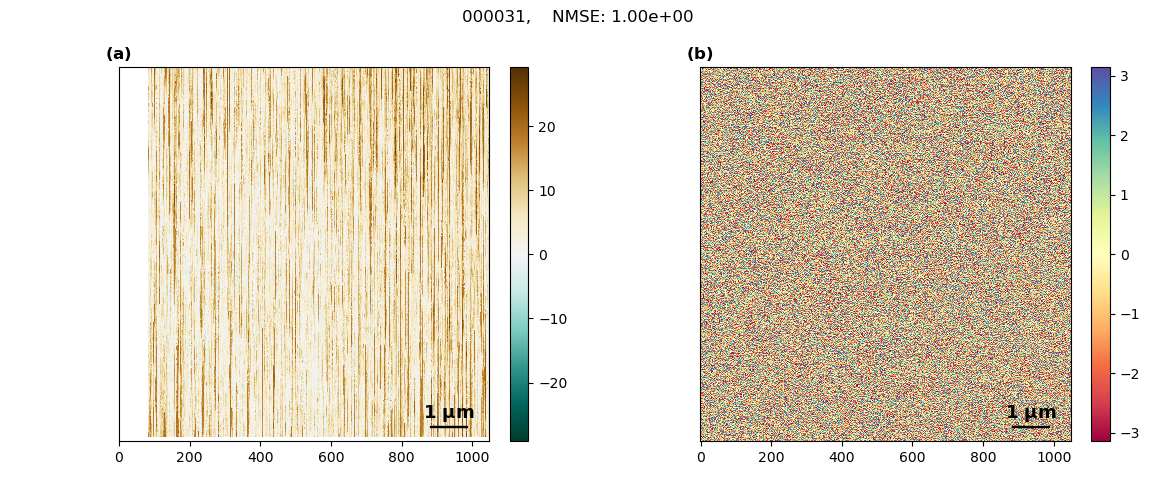

In [173]:
# Plot
def plot_diff(od_diff, phase_diff, clim_od, clim_ph, clim_type='maximum', savefigs=False):
    """
    clim_type [str]: can be either 'maximum' or 'mean'.
    """
    fig0, axs = plt.subplots(nrows=1, ncols=2, figsize=(4 * 2.9, 4 *1.2))
    fig0.set_tight_layout({"w_pad":2, "h_pad":0.1, "rect":  (0, 0, 1, 1)})
    
    # Plot with clim from max or min values
    #subfig28 = axs[0].imshow(od_diff, interpolation='None', vmin=-lim_od21, vmax=lim_od21, cmap='BrBG_r', origin='upper')#BWGdull)#(np.abs(obj2_) - np.abs(obj1_))/np.abs(obj1_), interpolation='None')
    #subfig29 = axs[1].imshow(phase_diff, interpolation='None', vmin=-lim_ph21, vmax=lim_ph21, cmap='Spectral', origin='upper')#BWG)
    
    # Plot with clim from mean and std values
    subfig28 = axs[0].imshow(od_diff, interpolation='None', vmin=clim_od[0], vmax=clim_od[1], cmap='BrBG_r', origin='upper')#BWGdull)#(np.abs(obj2_) - np.abs(obj1_))/np.abs(obj1_), interpolation='None')
    subfig29 = axs[1].imshow(phase_diff, interpolation='None', vmin=clim_ph[0], vmax=clim_ph[1], cmap='Spectral', origin='upper')#BWG)
    ######################################################
    plt.sca(axs[0])
    plt.title(r"$\bf{(a)}$ ", x=0)#loc='left')
    #plt.setp(axs[0], title='OD difference')
    #plt.ylabel('Real-time - offline', labelpad=10)
    plt.sca(axs[1])
    plt.title(r"$\bf{(b)}$ ", x=0)#loc='left')
    #plt.setp(axs[1], title='Phase difference')
    
    
    
    cbar4=plt.colorbar(subfig28, ax=axs[0], fraction=0.046, pad=0.04)#, ticks=[-0.000012, -0.000006, 0, 0.000006, 0.000012])
    #cbar4.set_label('[e-5]', labelpad=0)
    #cbar4.ax.set_yticklabels([r'-1.2', '-0.6', '0.0', '0.6', r'1.2'])
    cbar5=plt.colorbar(subfig29, ax=axs[1], fraction=0.046, pad=0.04)#, ticks=[-0.000014, -0.000007, 0, 0.000007, 0.000014])
    #cbar5.set_label('[e-5 rad]', labelpad=0)
    #cbar5.ax.set_yticklabels([r'-1.4', '-0.7', '0.0', '0.7', r'1.4'])
    
    for ax in axs.flatten():
        #ax.set_xticks([])
        ax.set_yticks([])
    ######################################################
    
    scalebar0 = AnchoredSizeBar(axs[0].transData, 1.0e-06 / LD.pr1_psize, r"1 $\mathbf{\mu}$m", loc='lower right', frameon=False, pad=0.3, borderpad=0.5, sep=2, label_top=True, size_vertical=1, fontproperties={'weight': 'bold', 'size':13}, color='black')
    scalebar1 = AnchoredSizeBar(axs[1].transData, 1.0e-06 / LD.pr1_psize, r"1 $\mathbf{\mu}$m", loc='lower right', frameon=False, pad=0.3, borderpad=0.5, sep=2, label_top=True, size_vertical=1, fontproperties={'weight': 'bold', 'size':13}, color='black')
    axs[0].add_artist(scalebar0)
    axs[1].add_artist(scalebar1)
    if len(LD.samplename) > 0:
        fig0.suptitle(f'{LD.samplename},    NMSE: {E12:.2e} ')
    plt.show()
    
    ######################################################
    #sh0 = phase_diff.shape[0]
    #sh1 = phase_diff.shape[1]
    ##axs[1].imshow(obj_abs*np.abs(illarea_pad), interpolation='None', origin='upper')
    #axs[1].hlines(marg-0.5, xmin=marg-0.5, xmax=sh0-marg-0.5, colors='r', lw=1)
    #axs[1].hlines(sh0-marg-0.5, xmin=marg-0.5, xmax=sh1-marg-0.5, colors='r', lw=1)
    #axs[1].vlines(marg-0.5, ymin=marg-0.5, ymax=sh0-marg-0.5, colors='r', lw=1)
    #axs[1].vlines(sh1-marg-0.5, ymin=marg-0.5, ymax=sh0-marg-0.5, colors='r', lw=1)
        
    ######################################################

    if savefigs:
        fig0.savefig(os.getcwd() + f'/figures/Off-RT_difference_{LD.samplename}.png', dpi=130)

    return fig0, axs

print(f'min/max(range) logamp3diff, phase_error21: {np.min(subfig28.get_array().data):.8f} {np.max(subfig28.get_array().data):.8f} ({(np.max(subfig28.get_array().data) - np.min(subfig28.get_array().data)):.8f}),  {np.min(phase_error21):.8f} {np.max(phase_error21):.8f} ({(np.max(phase_error21) - np.min(phase_error21)):.8f})')

mean_recons_amperr = [np.mean(np.abs(OD_diff21)), scipy.stats.sem(np.abs(OD_diff21).flatten())]
mean_recons_phaseerr = [np.mean(np.abs(phase_error21)), scipy.stats.sem(np.abs(phase_error21).flatten())]
print(f'mean abs OD error: {mean_recons_amperr[0]:.12f}')
print(f'mean abs phase error:  {mean_recons_phaseerr[0]:.12f}')
print(f'NMSE: {E12:.4e}')

    


#fig0, axs = plot_diff(od_diff=OD_diff21, phase_diff=phase_error21, clim_od=[vmin_od, vmax_od], clim_ph=[vmin_ph, vmax_ph], clim_type='mean', savefigs=False)

fig0, axs = plot_diff(od_diff=OD_diff21, phase_diff=phase_error21, clim_od=[-lim_od21, lim_od21], clim_ph=[-lim_ph21, lim_ph21], clim_type='mean', savefigs=False)


"""
ph error: -phase_shift:
min/max(range) logamp3diff, phase_error21: -0.10292793 0.15967950 (0.26260743),  -0.27997281 0.00260579 (0.28257859)
mean abs OD error: 0.007839050450
mean abs phase error:  0.102178612775
NMSE: 2.7397e-04

NMSE(obj1_,  obj2_): 2.74e-04
NMSE(obj2_,  obj1_): 2.74e-04
PSNR:  15.084121234454875
shift: [0. 0.]
np.mean(np.log(np.abs(obj_b))) -0.22247067505388032
limit  0.15967950462177138 0.279972806081231

[-0.03043379364474554, 0.030537059397982718] [-0.1422253782091674, -0.062131842056487335]

###########################################################################################################################
ph error: +phase_shift:
min/max(range) logamp3diff, phase_error21: -0.10292793 0.15967950 (0.26260743),  -0.13035792 0.15222067 (0.28257859)
mean abs OD error: 0.007839050450
mean abs phase error:  0.047455866409
NMSE: 2.7397e-04

NMSE(obj1_,  obj2_): 2.74e-04
NMSE(obj2_,  obj1_): 2.74e-04
PSNR:  15.084121234454875
shift: [0. 0.]
np.mean(np.log(np.abs(obj_b))) -0.22247067505388032
limit  0.15967950462177138 0.15222067109795567

[-0.03043379364474554, 0.030537059397982718] [0.007389507240242073, 0.08748304339292212]
""";

In [125]:
np.mean(phase_error21) # -0.10089235553410124, -0.08038575511180301


-0.10089235553410124

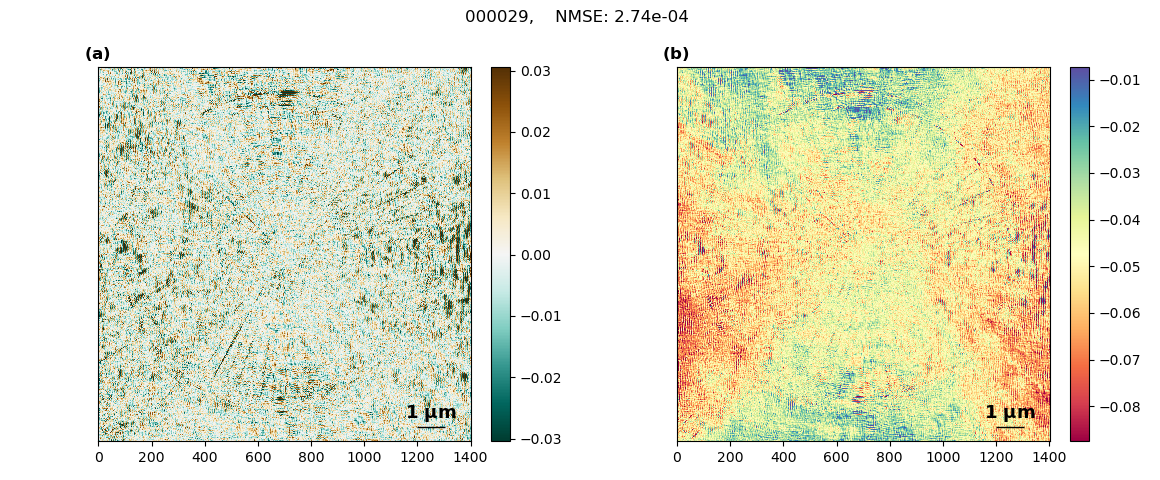

min/max(range) logamp3diff, phase_error21: -0.15957624 0.10303119 (0.26260743),  -0.15222067 0.13035792 (0.28257859)
mean abs OD error: 0.007838492375
mean abs phase error:  0.047455866409
NMSE: 2.7397e-04


In [32]:
# Plot original plot code before making it into a function
savefigs = False
fig0, axs = plt.subplots(nrows=1, ncols=2, figsize=(4 * 2.9, 4 *1.2))
fig0.set_tight_layout({"w_pad":2, "h_pad":0.1, "rect":  (0, 0, 1, 1)})

# Plot with clim from max or min values
#subfig28 = axs[0].imshow(OD_diff21, interpolation='None', vmin=-lim_od21, vmax=lim_od21, cmap='BrBG_r', origin='upper')#BWGdull)#(np.abs(obj2_) - np.abs(obj1_))/np.abs(obj1_), interpolation='None')
#subfig29 = axs[1].imshow(phase_error21, interpolation='None', vmin=-lim_ph21, vmax=lim_ph21, cmap='Spectral', origin='upper')#BWG)

# Plot with clim from mean and std values
subfig28 = axs[0].imshow(OD_diff21, interpolation='None', vmin=vmin_od, vmax=vmax_od, cmap='BrBG_r', origin='upper')#BWGdull)#(np.abs(obj2_) - np.abs(obj1_))/np.abs(obj1_), interpolation='None')
subfig29 = axs[1].imshow(phase_error21, interpolation='None', vmin=vmin_ph, vmax=vmax_ph, cmap='Spectral', origin='upper')#BWG)
######################################################
plt.sca(axs[0])
plt.title(r"$\bf{(a)}$ ", x=0)#loc='left')
#plt.setp(axs[0], title='OD difference')
#plt.ylabel('Real-time - offline', labelpad=10)
plt.sca(axs[1])
plt.title(r"$\bf{(b)}$ ", x=0)#loc='left')
#plt.setp(axs[1], title='Phase difference')



cbar4=plt.colorbar(subfig28, ax=axs[0], fraction=0.046, pad=0.04)#, ticks=[-0.000012, -0.000006, 0, 0.000006, 0.000012])
#cbar4.set_label('[e-5]', labelpad=0)
#cbar4.ax.set_yticklabels([r'-1.2', '-0.6', '0.0', '0.6', r'1.2'])
cbar5=plt.colorbar(subfig29, ax=axs[1], fraction=0.046, pad=0.04)#, ticks=[-0.000014, -0.000007, 0, 0.000007, 0.000014])
#cbar5.set_label('[e-5 rad]', labelpad=0)
#cbar5.ax.set_yticklabels([r'-1.4', '-0.7', '0.0', '0.7', r'1.4'])

for ax in axs.flatten():
    #ax.set_xticks([])
    ax.set_yticks([])
######################################################

scalebar0 = AnchoredSizeBar(axs[0].transData, 1.0e-06 / LD.pr1_psize, r"1 $\mathbf{\mu}$m", loc='lower right', frameon=False, pad=0.3, borderpad=0.5, sep=2, label_top=True, size_vertical=1, fontproperties={'weight': 'bold', 'size':13}, color='black')
scalebar1 = AnchoredSizeBar(axs[1].transData, 1.0e-06 / LD.pr1_psize, r"1 $\mathbf{\mu}$m", loc='lower right', frameon=False, pad=0.3, borderpad=0.5, sep=2, label_top=True, size_vertical=1, fontproperties={'weight': 'bold', 'size':13}, color='black')
axs[0].add_artist(scalebar0)
axs[1].add_artist(scalebar1)
if len(LD.samplename) > 0:
    fig0.suptitle(f'{LD.samplename},    NMSE: {E12:.2e} ')
plt.show()

######################################################
#sh0 = phase_error21.shape[0]
#sh1 = phase_error21.shape[1]
##axs[1].imshow(obj_abs*np.abs(illarea_pad), interpolation='None', origin='upper')
#axs[1].hlines(marg-0.5, xmin=marg-0.5, xmax=sh0-marg-0.5, colors='r', lw=1)
#axs[1].hlines(sh0-marg-0.5, xmin=marg-0.5, xmax=sh1-marg-0.5, colors='r', lw=1)
#axs[1].vlines(marg-0.5, ymin=marg-0.5, ymax=sh0-marg-0.5, colors='r', lw=1)
#axs[1].vlines(sh1-marg-0.5, ymin=marg-0.5, ymax=sh0-marg-0.5, colors='r', lw=1)
    
######################################################
print(f'min/max(range) logamp3diff, phase_error21: {np.min(subfig28.get_array().data):.8f} {np.max(subfig28.get_array().data):.8f} ({(np.max(subfig28.get_array().data) - np.min(subfig28.get_array().data)):.8f}),  {np.min(phase_error21):.8f} {np.max(phase_error21):.8f} ({(np.max(phase_error21) - np.min(phase_error21)):.8f})')

mean_recons_amperr = [np.mean(np.abs(OD_diff21)), scipy.stats.sem(np.abs(OD_diff21).flatten())]
mean_recons_phaseerr = [np.mean(np.abs(phase_error21)), scipy.stats.sem(np.abs(phase_error21).flatten())]
print(f'mean abs OD error: {mean_recons_amperr[0]:.12f}')
print(f'mean abs phase error:  {mean_recons_phaseerr[0]:.12f}')
print(f'NMSE: {E12:.4e}')


if savefigs:
    fig0.savefig(os.getcwd() + f'/figures/Off-RT_difference_{LD.samplename}.png', dpi=130)

"""
ph error: -phase_shift:
min/max(range) logamp3diff, phase_error21: -0.10292793 0.15967950 (0.26260743),  -0.27997281 0.00260579 (0.28257859)
mean abs OD error: 0.007839050450
mean abs phase error:  0.102178612775
NMSE: 2.7397e-04

NMSE(obj1_,  obj2_): 2.74e-04
NMSE(obj2_,  obj1_): 2.74e-04
PSNR:  15.084121234454875
shift: [0. 0.]
np.mean(np.log(np.abs(obj_b))) -0.22247067505388032
limit  0.15967950462177138 0.279972806081231

[-0.03043379364474554, 0.030537059397982718] [-0.1422253782091674, -0.062131842056487335]

###########################################################################################################################
ph error: +phase_shift:
min/max(range) logamp3diff, phase_error21: -0.10292793 0.15967950 (0.26260743),  -0.13035792 0.15222067 (0.28257859)
mean abs OD error: 0.007839050450
mean abs phase error:  0.047455866409
NMSE: 2.7397e-04

NMSE(obj1_,  obj2_): 2.74e-04
NMSE(obj2_,  obj1_): 2.74e-04
PSNR:  15.084121234454875
shift: [0. 0.]
np.mean(np.log(np.abs(obj_b))) -0.22247067505388032
limit  0.15967950462177138 0.15222067109795567

[-0.03043379364474554, 0.030537059397982718] [0.007389507240242073, 0.08748304339292212]
""";

In [23]:
sh1 = LD.obj1.shape
sh2 = LD.obj2.shape
#LD.obj1.shape, LD.obj2[:sh1[0], :sh1[2]].shape
obj1_.shape, obj2_.shape

((1406, 1403), (1406, 1403))

In [24]:
E12 = NMSE(obj1_, obj2_, printoutput=True)

NMSE(obj1_,  obj2_): 2.74e-04
NMSE(obj2_,  obj1_): 2.74e-04
PSNR:  15.084121234454875


In [25]:
"""
000029:
scale : NMSE
60: 4.8353e-04
50: 3.2403e-04
45: 2.7397e-04
40: 2.4561e-04
30: 1.9347e-04 (spokes showing)
20: 1.6844e-04
"""

'\n000029:\nscale : NMSE\n60: 4.8353e-04\n50: 3.2403e-04\n45: 2.7397e-04\n40: 2.4561e-04\n30: 1.9347e-04 (spokes showing)\n20: 1.6844e-04\n'

<h2>Calculate mean abs values for all overlaps</h2>

In [18]:
marg = ((min(LD10.sh) - max(LD10.sh1)) // 2) + int(max(LD10.sh1) // 3.15)#3.8)
mean_offline_amperr = {}
mean_realtime_amperr = {}
mean_offline_phaseerr = {}
mean_realtime_phaseerr = {}
mean_recons_amperr = {}
mean_recons_phaseerr = {}
for nr, LD in zip(stepnumbers, LDs):
    obj1_ = np.array(LD.obj1_ramp_pad[marg:-marg,marg:-marg].copy())
    obj2_ = np.array(LD.obj2_ramp_pad[marg:-marg,marg:-marg].copy())
    obj_GT = np.array(LD.obj_ramp[marg:-marg,marg:-marg].copy())

    OD_diff10, phase_error10 = get_difference(obj1_, obj_GT)
    OD_diff20, phase_error20 = get_difference(obj2_, obj_GT)
    OD_diff21, phase_error21 = get_difference(obj2_, obj1_)
    
    mean_offline_amperr[nr] = [np.mean(np.abs( OD_diff10 )), scipy.stats.sem(np.abs( OD_diff10 ).flatten())]
    mean_realtime_amperr[nr] = [np.mean(np.abs( OD_diff20 )), scipy.stats.sem(np.abs( OD_diff20 ).flatten())]
    mean_offline_phaseerr[nr] = [np.mean(np.abs(phase_error10)), scipy.stats.sem(np.abs(phase_error10).flatten())]
    mean_realtime_phaseerr[nr] = [np.mean(np.abs(phase_error20)), scipy.stats.sem(np.abs(phase_error20).flatten())]
    mean_recons_amperr[nr] = [np.mean(np.abs(OD_diff21)), scipy.stats.sem(np.abs(OD_diff21).flatten())]
    mean_recons_phaseerr[nr] = [np.mean(np.abs(phase_error21)), scipy.stats.sem(np.abs(phase_error21).flatten())]
    

# print
for nr, LD in zip(stepnumbers, LDs):
    print(f"\n{nr} px ({str(LD.fname1[-9:-5]+'/'+ LD.fname2[-9:-5]):<13} iterations): ")
    all_means = np.array([mean_offline_amperr[nr][0], mean_realtime_amperr[nr][0], mean_recons_amperr[nr][0], mean_offline_phaseerr[nr][0], mean_realtime_phaseerr[nr][0], mean_recons_phaseerr[nr][0]])
    all_sems = np.array([mean_offline_amperr[nr][1], mean_realtime_amperr[nr][1], mean_recons_amperr[nr][1], mean_offline_phaseerr[nr][1], mean_realtime_phaseerr[nr][1], mean_recons_phaseerr[nr][1]])
    all_means_sem_str = []
    for mean, sem in zip(all_means, all_sems):
        all_means_sem_str.append( f"{str(f'{mean:.2e}'+f' +- {sem:.2e}'):<22}" )

    #print(f"{'Iteration':<13} {'offline_amperr':<22} {'realtime_amperr':<22} {'recons_amperr':<22} {'offline_phaseerr':<22} {'realtime_phaseerr':<22} {'recons_phaseerr':<22}")
    #print(f"{str(LD.fname1[-9:-5]+'/'+ LD.fname2[-9:-5]):<13} {all_means_sem_str[0]} {all_means_sem_str[1]} {all_means_sem_str[2]} {all_means_sem_str[3]} {all_means_sem_str[4]} {all_means_sem_str[5]}")


    print(f"Offline - Ground truth:   {all_means_sem_str[0]}, {all_means_sem_str[3]}")
    print(f"Real-time - Ground truth: {all_means_sem_str[1]}, {all_means_sem_str[4]}")
    print(f"Real-time - Offline:      {all_means_sem_str[2]}, {all_means_sem_str[5]}")


# Save this data to file
abs_OD_diff_mean=np.array([list(mean_offline_amperr.values()), list(mean_realtime_amperr.values()), list(mean_recons_amperr.values())])[:,:,0]
abs_OD_diff_se=np.array([list(mean_offline_amperr.values()), list(mean_realtime_amperr.values()), list(mean_recons_amperr.values())])[:,:,1]
abs_phase_diff_mean=np.array([list(mean_offline_phaseerr.values()), list(mean_realtime_phaseerr.values()), list(mean_recons_phaseerr.values())])[:,:,0]
abs_phase_diff_se=np.array([list(mean_offline_phaseerr.values()), list(mean_realtime_phaseerr.values()), list(mean_recons_phaseerr.values())])[:,:,1]
np.savez("mean_diff_data.npz", abs_OD_diff_mean=abs_OD_diff_mean, abs_OD_diff_se=abs_OD_diff_se, abs_phase_diff_mean=abs_phase_diff_mean, abs_phase_diff_se=abs_phase_diff_se)
print('saved data')



#np.array(list(mean_offline_amperr.values()), list(mean_realtime_amperr.values()))[:,0]

NameError: name 'LD10' is not defined

<h1>Extra</h1>

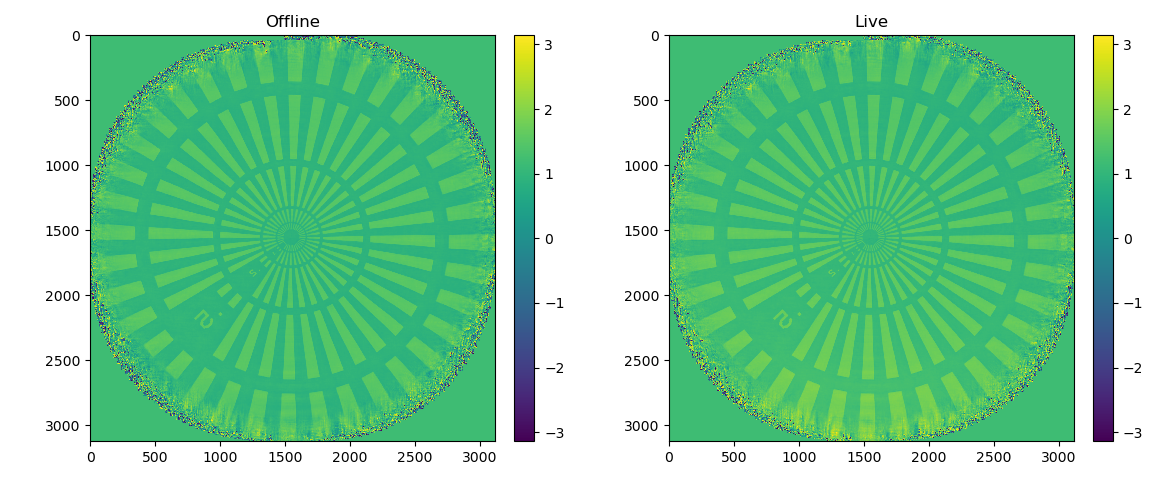

In [14]:
#plot obj phase
fig2, axs = plt.subplots(nrows=1, ncols=2, figsize=(4 * 2.9, 4 *1.2))
fig2.set_tight_layout({"w_pad":2, "h_pad":0.1, "rect":  (0, 0, 1, 1)})

subfig0 = axs[0].imshow(np.angle(LD.obj1), interpolation='None')#BWGdull)#(np.abs(obj2_) - np.abs(obj1_))/np.abs(obj1_), interpolation='None')
subfig1 = axs[1].imshow(np.angle(LD.obj2), interpolation='None')#BWG)
plt.setp(axs[0], title='Offline')
plt.setp(axs[1], title='Live')
cbar0=plt.colorbar(subfig0, ax=axs[0], fraction=0.046, pad=0.04)
cbar1=plt.colorbar(subfig1, ax=axs[1], fraction=0.046, pad=0.04)
plt.show()

In [16]:
np.set_printoptions(linewidth=175) # default = 75
a = np.array([1.1, 0.9, 0.2, 0.1, 0.01], dtype='float32')
a_=1.0 - a
print('a_\n', a_)
exact_vals = -0.1, 0.1, 0.8, 0.8, 0.99
a_err = np.abs((exact_vals - a_))
a_err_rel = np.abs((exact_vals - a_)/exact_vals)
print('a_err\n', a_err)
print('a_err_rel\n', a_err_rel)

a_
 [-0.10000002  0.10000002  0.8         0.9         0.99      ]
a_err
 [2.38418579e-08 2.38418579e-08 1.19209289e-08 9.99999762e-02 9.53674317e-09]
a_err_rel
 [2.38418579e-07 2.38418579e-07 1.49011611e-08 1.24999970e-01 9.63307391e-09]


<h3>plot ramps</h3>

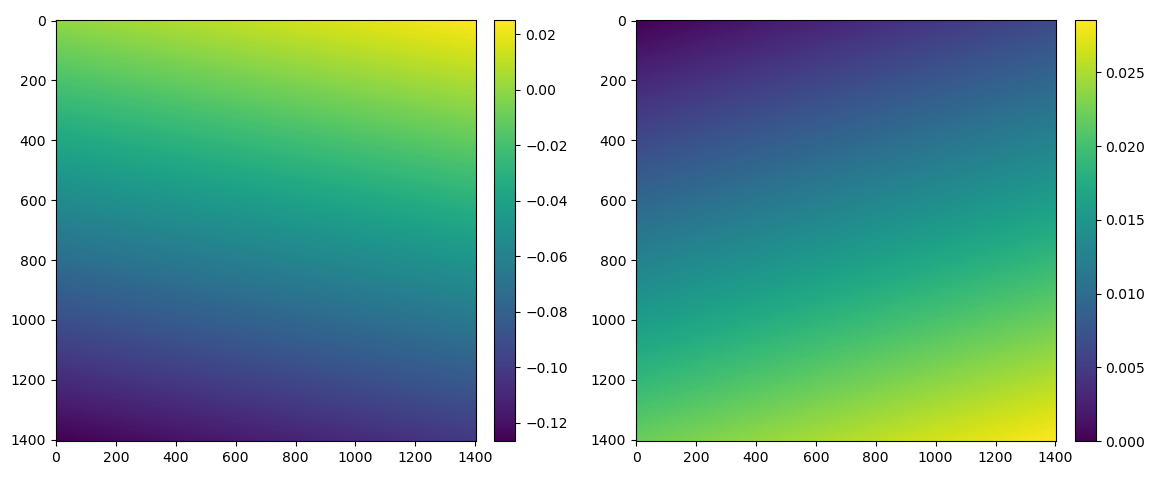

In [65]:
#plot ramps

fig0, axs = plt.subplots(nrows=1, ncols=2, figsize=(4 * 2.9, 4 *1.2))
fig0.set_tight_layout({"w_pad":2, "h_pad":0.1, "rect":  (0, 0, 1, 1)})

k=0
subfig0 = axs[0].imshow(np.angle(all_ramps1[k]), interpolation='None')#BWGdull)#(np.abs(obj2_) - np.abs(obj1_))/np.abs(obj1_), interpolation='None')
subfig1 = axs[1].imshow(np.angle(all_ramps2[k]), interpolation='None')#BWG)
cbar0=plt.colorbar(subfig0, ax=axs[0], fraction=0.046, pad=0.04)#, ticks=[-0.000012, -0.000006, 0, 0.000006, 0.000012])
cbar1=plt.colorbar(subfig1, ax=axs[1], fraction=0.046, pad=0.04)#, ticks=[-0.000012, -0.000006, 0, 0.000006, 0.000012])



<h3>testing if order of things in get_difference() matters..</h3>

In [8]:
# testing if order of things in get_difference() matters..
"""phase_error01 = np.angle(obj1_*np.exp(1.0j*phase_shift01))-np.angle(obj_GT)
phase_error01[phase_error01 < np.pi] += 2*np.pi
phase_error01[phase_error01 > np.pi] -= 2*np.pi

obj2_ *= np.mean(np.abs(obj1_)/np.abs(obj2_))
shift03,_,phase_shift03 = phase_cross_correlation(obj1_, obj2_)

phase_error03 = np.angle(obj2_)+phase_shift03 -np.angle(obj1_)
phase_error03[phase_error03 < np.pi] += 2*np.pi
phase_error03[phase_error03 > np.pi] -= 2*np.pi
""";

################################################## method 0
obj_a = np.array(LD.obj1[start_M:end_M, start_N:end_N].copy())
obj_b = np.array(LD.obj2[start_M:end_M, start_N:end_N].copy())


# Apply translational shift (was not needed in last paper)
shift_ab,_,phase_shift = phase_cross_correlation(obj_a, obj_b, upsample_factor=1)
obj_a = shift(obj_a, shift_ab, mode="constant", cval=0+0j)

# Remove phase ramp
W1 = LD.rampweight_(obj_a, scale=rampscale)#
all_ramps1 = {}
all_ramps2 = {}
#W1 = LD.rampweight(obj_a, scale=100)#
for nr_removal in range(5):
    obj_a, all_ramps1[nr_removal] = rmphaseramp(obj_a, W1, return_phaseramp=True)
    obj_b, all_ramps2[nr_removal] = rmphaseramp(obj_b, W1, return_phaseramp=True)

# Scale the reconstruction to the solution
obj_b *= np.mean(np.abs(obj_a) / np.abs(obj_b)) # Scale the reconstruction to the solution

# Apply phase shift
phase_error0 = np.angle(obj_b) + phase_shift - np.angle(obj_a)
phase_error0[phase_error0 < np.pi] += 2*np.pi
phase_error0[phase_error0 > np.pi] -= 2*np.pi

OD_diff0 = np.log(np.abs(obj_b)) - np.log(np.abs(obj_a))

################################################## method 1
obj_a = np.array(LD.obj1[start_M:end_M, start_N:end_N].copy())
obj_b = np.array(LD.obj2[start_M:end_M, start_N:end_N].copy())


# Apply translational shift (was not needed in last paper)
shift_ab,_,phase_shift = phase_cross_correlation(obj_a, obj_b, upsample_factor=1)
obj_a = shift(obj_a, shift_ab, mode="constant", cval=0+0j)

# Remove phase ramp
W1 = LD.rampweight_(obj_a, scale=rampscale)#
all_ramps1 = {}
all_ramps2 = {}
#W1 = LD.rampweight(obj_a, scale=100)#
for nr_removal in range(5):
    obj_a, all_ramps1[nr_removal] = rmphaseramp(obj_a, W1, return_phaseramp=True)
    obj_b, all_ramps2[nr_removal] = rmphaseramp(obj_b, W1, return_phaseramp=True)

# Scale the reconstruction to the solution
obj_b *= np.mean(np.abs(obj_a) / np.abs(obj_b)) # Scale the reconstruction to the solution

# Apply phase shift
phase_error1 = np.angle(obj_b*np.exp(1.0j*phase_shift))-np.angle(obj_a)
#phase_error = np.angle(obj_b) + phase_shift - np.angle(obj_a)
phase_error1[phase_error1 < np.pi] += 2*np.pi
phase_error1[phase_error1 > np.pi] -= 2*np.pi

OD_diff1 = np.log(np.abs(obj_b)) - np.log(np.abs(obj_a))


################################################## method 2
obj_a = np.array(LD.obj1[start_M:end_M, start_N:end_N].copy())
obj_b = np.array(LD.obj2[start_M:end_M, start_N:end_N].copy())


# Apply translational shift (was not needed in last paper)
shift_ab,_,phase_shift = phase_cross_correlation(obj_a, obj_b, upsample_factor=1)
obj_a = shift(obj_a, shift_ab, mode="constant", cval=0+0j)


# Apply phase shift
obj_b *= np.exp(1.0j*phase_shift)

# Scale the reconstruction to the solution
obj_b *= np.mean(np.abs(obj_a) / np.abs(obj_b)) # Scale the reconstruction to the solution

# Remove phase ramp
W1 = LD.rampweight_(obj_a, scale=rampscale)#
all_ramps1 = {}
all_ramps2 = {}
#W1 = LD.rampweight(obj_a, scale=100)#
for nr_removal in range(5):
    obj_a, all_ramps1[nr_removal] = rmphaseramp(obj_a, W1, return_phaseramp=True)
    obj_b, all_ramps2[nr_removal] = rmphaseramp(obj_b, W1, return_phaseramp=True)

    
# Calculate error
phase_error2 = np.angle(obj_b)-np.angle(obj_a)
#phase_error = np.angle(obj_b) + phase_shift - np.angle(obj_a)

phase_error2[phase_error2 < np.pi] += 2*np.pi
phase_error2[phase_error2 > np.pi] -= 2*np.pi

OD_diff2 = np.log(np.abs(obj_b)) - np.log(np.abs(obj_a))




####################################################################################################

####################################################################################################
print(np.max(np.abs(phase_error1-phase_error0)), np.max(np.abs(OD_diff1[np.where(np.isfinite(OD_diff1))]-OD_diff0[np.where(np.isfinite(OD_diff0))])))

print(np.max(np.abs(phase_error2-phase_error1)), np.max(np.abs(OD_diff2[np.where(np.isfinite(OD_diff2))]-OD_diff0[np.where(np.isfinite(OD_diff1))])))

####################################################################################################

####################################################################################################

phase_error21 = phase_error0
lim_ph21 = np.max(np.abs([ np.min(phase_error21), np.max(phase_error21[np.where(np.isfinite(OD_diff21))])]))
print('limit ', lim_ph21)

NameError: name 'start_M' is not defined

<h3>testing the limits of different upsample factors</h3>

In [221]:
# testing the limits of different upsample factors
scale=40
start_M, end_M, start_N, end_N = LD.get_margin(LD.obj1, scale=scale)
#marg = 350
obj1_ = np.array(LD.obj1[start_M:end_M, start_N:end_N].copy())
obj2_ = np.array(LD.obj2[start_M:end_M, start_N:end_N].copy())


upsamps = [1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 16, 20, 32, 50, 64, 70, 100, 128, 200, 256]#, 512, 1024]
upsamps = list(np.arange(1,513))
binars = [   2,    4,    8,   16,   32,   64,  128,  256,  512, 1024]
lim_ods = []
lim_phs = []
means = []
for ups in upsamps:
    if ups in binars:
        pling = '***'
    else:
        pling = ''
    print(f'upsample {ups} {pling}')
    OD_diff21, phase_error21, all_ramps1, all_ramps2 = get_difference(obj2_, obj1_, rampscale=100, upsamp=ups)
    
    lim_od21 = np.max(np.abs([ np.min(OD_diff21), np.max(OD_diff21[np.where(np.isfinite(OD_diff21))])])) # the shift function causes inf values in the logabsdiff on 2 of the edges.
    #lim_ph21 = np.max(np.abs([ np.min(phase_error21), np.max(phase_error21)]))
    lim_ph21 = np.max(np.abs([ np.min(phase_error21), np.max(phase_error21[np.where(np.isfinite(OD_diff21))])]))
    
    print('limit ', lim_od21, lim_ph21, '\n\n')
    
    lim_ods.append(lim_od21)
    lim_phs.append(lim_ph21)
    mean = [np.mean(np.abs(OD_diff21)), np.mean(np.abs(phase_error21))]
    means.append(mean)


upsample 1 
shift: [0. 0.]
np.mean(np.log(np.abs(obj_b))) -0.22397526468952833
limit  0.0647401885560916 0.17118482384067324 


upsample 2 ***
shift: [0. 0.]
np.mean(np.log(np.abs(obj_b))) -0.22397526468952833
limit  0.0647401885560916 0.17118483874183443 


upsample 3 
shift: [0. 0.]
np.mean(np.log(np.abs(obj_b))) -0.22397526468952833
limit  0.0647401885560916 0.17118483874183443 


upsample 4 ***
shift: [0.25 0.  ]
np.mean(np.log(np.abs(obj_b))) -0.2257361081934441
limit  0.0844549382957861 1.5817876810958733 


upsample 5 
shift: [0.2 0. ]
np.mean(np.log(np.abs(obj_b))) -0.22574172170420223
limit  0.08075175768554149 1.5669140091192997 


upsample 6 
shift: [0.16666667 0.        ]
np.mean(np.log(np.abs(obj_b))) -0.22574484191394306
limit  0.07831032394847964 1.5567575427402902 


upsample 7 
shift: [0.14285715 0.        ]
np.mean(np.log(np.abs(obj_b))) -0.22574677391260786
limit  0.0765813271887506 1.5522204800322053 


upsample 8 ***
shift: [0.125 0.   ]
np.mean(np.log(np.abs(obj_b

In [254]:
data = {'lim_od21': lim_ods, 'lim_ph21': lim_phs, 'upsample_factors': upsamps, 'note': 'abs limits of reconstruction 000027_00, cropped using scale=40. Order of calculations in get_difference() was: translational shift, rampremoval, scaling, phaseshift and error calculations'}
np.savez('000027_00_LimitsOfUpsampleFactor', lim_od21=lim_ods, lim_ph21=lim_phs, upsample_factors=upsamps, note='abs limits of reconstruction 000027_00, cropped using scale=40. Order of calculations in get_difference() was: translational shift, rampremoval, scaling, phaseshift and error calculations')

In [ ]:
data0 = np.load('000027_00_LimitsOfUpsampleFactor.npz', allow_pickle=True)
data0['lim_od21']

<h3>other</h3>

In [48]:
np.get_printoptions()

{'edgeitems': 3,
 'threshold': 1000,
 'floatmode': 'maxprec',
 'precision': 8,
 'suppress': False,
 'linewidth': 175,
 'nanstr': 'nan',
 'infstr': 'inf',
 'sign': '-',
 'formatter': None,
 'legacy': False}

In [56]:
for nr in stepnumbers:
    print(nr)
    print(mean_offline_amperr[nr][0], mean_offline_amperr[nr][0]-mean_offline_amperr[nr][1], mean_offline_amperr[nr][0]+mean_offline_amperr[nr][1])
    print(mean_realtime_amperr[nr][0], mean_realtime_amperr[nr][0]-mean_realtime_amperr[nr][1], mean_realtime_amperr[nr][0]+mean_realtime_amperr[nr][1])
    print('')

10
7.813340665048949e-05 7.774427009245505e-05 7.852254320852393e-05
7.813088683076305e-05 7.77418111631964e-05 7.85199624983297e-05

19
0.00013250162956861974 0.00013186265294145555 0.00013314060619578393
0.00013252602046783153 0.00013188705440710878 0.00013316498652855428

27
0.00019282647981021668 0.00019190043250750876 0.0001937525271129246
0.000192851578656257 0.00019192535724096125 0.00019377780007155278

35
0.000256359709315056 0.0002550944877321023 0.00025762493089800974
0.00025304682783542536 0.0002517934754951446 0.0002543001801757061

40
0.000310371877654004 0.0003088150153384977 0.00031192873996951025
0.000299249519606099 0.00029774420252146126 0.00030075483669073674



In [52]:
stepnumbers

['10', '19', '27', '35', '40']

In [44]:
np.where(np.isinf(OD_diff21)), np.where(np.isinf(phase_error21))

((array([   0,    1,    2, ..., 1405, 1405, 1405]),
  array([   0,    0,    0, ..., 1400, 1401, 1402])),
 (array([], dtype=int64), array([], dtype=int64)))

In [55]:
#OD_diff21[:5,0] # inf
all(np.isinf(OD_diff21[-1,:]))

True

In [39]:
2808/2

1404.0

In [66]:
"""
bundlerextension 
contrib 
execute 
kernel
kernelspec 
lab 
labextension 
labhub 
migrate 
nbclassic 
nbconvert
nbextension 
nbextensions_configurator 
notebook 
run 
server
serverextension 
troubleshoot 
trust
"""

OSError: "/bin/zsh" shell not found

In [67]:
import jinja2


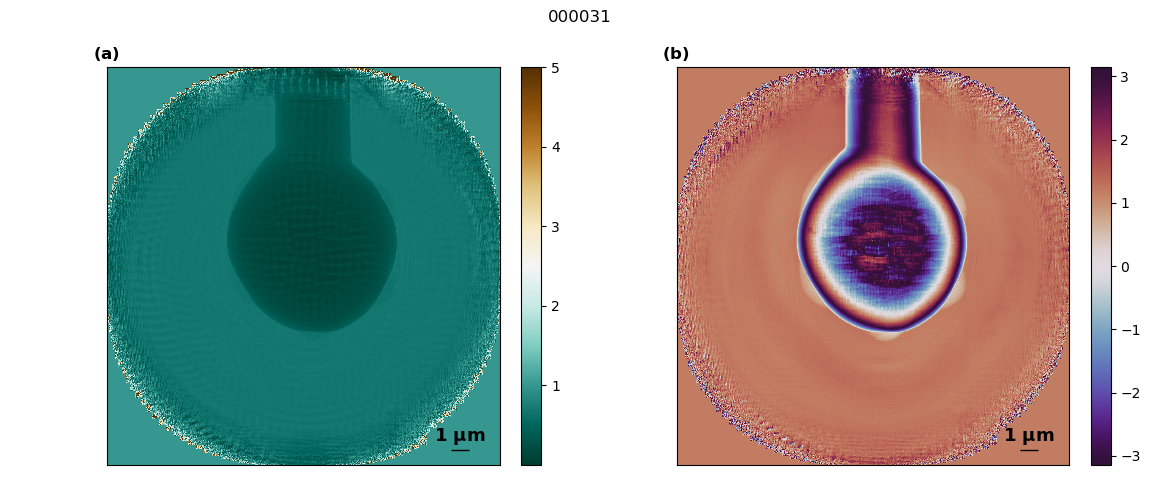

In [187]:
fig1, axs = plt.subplots(nrows=1, ncols=2, figsize=(4 * 2.9, 4 *1.2))
fig1.set_tight_layout({"w_pad":2, "h_pad":0.1, "rect":  (0, 0, 1, 1)})

od = np.abs(LD.obj1)
phase = np.angle(LD.obj1)

clim_od = [None,5] #LD.get_vminvmax(od)
clim_ph = [None,None] #LD.get_vminvmax(phase)
# Plot with clim from mean and std values
subfig30 = axs[0].imshow(od, interpolation='None', vmin=clim_od[0], vmax=clim_od[1], cmap='BrBG_r', origin='upper')
subfig31 = axs[1].imshow(phase, interpolation='None', vmin=clim_ph[0], vmax=clim_ph[1], cmap='twilight_shifted', origin='upper')#BWG)
######################################################
plt.sca(axs[0])
plt.title(r"$\bf{(a)}$ ", x=0)

plt.sca(axs[1])
plt.title(r"$\bf{(b)}$ ", x=0)#loc='left')


cbar6=plt.colorbar(subfig30, ax=axs[0], fraction=0.046, pad=0.04)
cbar7=plt.colorbar(subfig31, ax=axs[1], fraction=0.046, pad=0.04)


for ax in axs.flatten():
    ax.set_xticks([])
    ax.set_yticks([])
######################################################

scalebar0 = AnchoredSizeBar(axs[0].transData, 1.0e-06 / LD.pr1_psize, r"1 $\mathbf{\mu}$m", loc='lower right', frameon=False, pad=0.3, borderpad=0.5, sep=2, label_top=True, size_vertical=1, fontproperties={'weight': 'bold', 'size':13}, color='black')
scalebar1 = AnchoredSizeBar(axs[1].transData, 1.0e-06 / LD.pr1_psize, r"1 $\mathbf{\mu}$m", loc='lower right', frameon=False, pad=0.3, borderpad=0.5, sep=2, label_top=True, size_vertical=1, fontproperties={'weight': 'bold', 'size':13}, color='black')
axs[0].add_artist(scalebar0)
axs[1].add_artist(scalebar1)
if len(LD.samplename) > 0:
    fig1.suptitle(f'{LD.samplename}')
plt.show()


In [178]:
np.min(phase), np.max(phase), np.min(od), np.max(od)

(-3.1415846, 3.1415887, 0.0007815148, 1455.4725)

NameError: name 'BWG' is not defined